PROJECT   : ANALISIS FAKTOR KEMANCETAN LALU LINTAS KOTA SURABAYA

Sandi Ardi Prayitno    24031554037
Sabrina Miftakhul Jana 24031554148
Kelompok 5
Kelas 2024D

Data    1 : Data Lalu Lintas Harian Rata-Rata (LHR)
            https://dishub.surabaya.go.id/portal/elalin/lhr'
        2 : Data Penduduk
            https://surabayakota.bps.go.id/id/statistics-table/3/V1ZSbFRUY3lTbFpEYTNsVWNGcDZjek53YkhsNFFUMDkjMw==/jumlah-penduduk--laju-pertumbuhan-penduduk--distribusi-persentase-penduduk--kepadatan-penduduk--rasio-jenis-kelamin-penduduk-menurut-kecamatan-di-kota-surabaya--2024.html?year=2024
        3 : Data Kondisi Jalan Kota Surabaya
            https://ckan.surabaya.go.id/dataset/2600-10772-181

# PENGUMPULAN DATA

In [61]:
# SCRAPPING DATA LALU LINTAS HARIAN
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re

url = 'https://dishub.surabaya.go.id/portal/elalin/lhr'
response = requests.get(url)
response.raise_for_status()
soup = BeautifulSoup(response.text, 'html.parser')
table = soup.find('table')

if table:
    header_html = table.find_all('th')
    if not header_html:
        header_html = table.find('tr').find_all('td')
    headers = [h.get_text(strip=True) for h in header_html]
    rows = table.find_all('tr')[1:]
    data = []
    for row in rows:
        cols = row.find_all('td')
        cols_text = [c.get_text(strip=True) for c in cols]
        data.append(cols_text)
    df_lhr = pd.DataFrame(data, columns=headers)
    df_lhr.to_csv('raw_data_lalu_lintas_harian.csv', index=False)
df_lhr

,Nama Jalan,Sepeda Motor,Mobil Pribadi,Angkot,Bus Mini,Pickup / Box,Mini Truk,Bus Besar,Truk 2 Sumbu,Truk 3 Sumbu,Truk Gandeng,Trailer,Kend Tak Bermotor,Tahun Tahap
0,Adityawarman,94.572,30.049,421,49,1.094,215,40,42,2,0,0,390,2019 (2)
1,Adityawarman,94.572,30.049,421,49,1.094,215,40,52,2,0,0,390,2019 (1)
2,Basuki Rahmat,163.774,56.500,698,27,840,31,90,4,0,0,0,3.542,2019 (2)
3,Basuki Rahmat,121.455,25.879,501,66,765,58,83,5,0,0,0,2.210,2019 (1)
4,Blauran,29.627,268,44,798,49,26,10,0,0,0,171,0,2019 (2)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,DR. IR. H SOEKARNO,150.621,47.409,312,93,1.406,178,69,26,0,0,0,261,2019 (1)
98,RAYA ITS,58.333,34.341,29,2,317,56,1,0,0,0,0,116,2019 (2)
99,RAYA ITS,48.361,18.464,249,53,1.198,71,50,14,0,0,0,363,2019 (1)
100,LAGUNA PUTIH TAMBAK,52.539,47.072,210,114,1.213,85,0,19,0,0,0,643,2019 (2)


In [62]:
# # BACA DATA PEMELIHARAAN JALAN
# df_pemeliharaan = pd.read_csv(r'/content/Data Pemeliharaan Jalan.csv')
# df_pemeliharaan
# DROP KOLOM DENGAN NULL VALUE
# df_pemeliharaan = df_pemeliharaan.drop(['_id', 'nama_node1', 'nama_node2', 'kode_node1', 'kode_node2', 'kode_jalan'], axis=1)
# df_pemeliharaan

In [63]:
# SCRAPPING PANJANG JALAN DAN PRASARANA YANG DIBANGUN
dataset_url = "https://ckan.surabaya.go.id/api/3/action/package_show?id=2600-10772-181"
response = requests.get(dataset_url)
data = response.json()
resources = data['result']['resources']

dataframe = []
for res in resources:
  if res ['format'].lower() == 'csv':
    try:
      df = pd.read_csv(res['url'], delimiter=';')
      dataframe.append((res['name'], df))
    except Exception as e:
      print(f"Error reading CSV file {res['name']}: {e}")
# dataframe
df_pembangunan = pd.concat([df for name, df in dataframe],ignore_index=True)
df_pembangunan.to_csv('raw_data_pembangunan.csv', index=False)
df_pembangunan

,nama_node1,nama_node2,kode_node1,kode_node2,kode_jalan,tanggal_mulai,tanggal_selesai,nama_jalan,kelurahan,kecamatan,...,lebar_jalan,luasan_pengerjaan,jenis_pekerjaan,deskripsi_pembangunan,keterangan_sk,panjang_sk,total_panjang_jalan_yang_dipelihara,total_lebar_jalan_yang_dipelihara,total_luas_jalan_yang_dipelihara,"""nama_node1"""
0,NaN,NaN,NaN,NaN,NaN,2023-09-06 00:00:00,2023-09-06 00:00:00,Jl. A. R. Hakim,Kel. Keputih,Kec. Sukolilo,...,35.0,350.0000,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,Ada dalam SK Jalan 2016,2468.0,131.0,85.0,1528.0,NaN
1,NaN,NaN,NaN,NaN,NaN,2023-09-06 00:00:00,2023-09-06 00:00:00,Jl. A. R. Hakim,Kel. Keputih,Kec. Sukolilo,...,25.0,825.0000,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,Ada dalam SK Jalan 2016,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,2023-09-06 00:00:00,2023-09-06 00:00:00,Jl. A. R. Hakim,Kel. Keputih,Kec. Sukolilo,...,1.0,35.0000,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,Ada dalam SK Jalan 2016,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,2023-09-06 00:00:00,2023-09-06 00:00:00,Jl. A. R. Hakim,Kel. Keputih,Kec. Sukolilo,...,5.0,50.0000,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,Ada dalam SK Jalan 2016,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,2023-09-09 00:00:00,2023-09-09 00:00:00,Jl. A. R. Hakim,Kel. Klampis Ngasem,Kec. Sukolilo,...,15.0,210.0000,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,Ada dalam SK Jalan 2016,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23150,NaN,NaN,NaN,NaN,NaN,2025-03-27 00:00:00,2025-03-27 00:00:00,Jl. Wonosari Lor,Kel. Wonokusumo,Kec. Semampir,...,1.0,4.6350,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,NaN,NaN,NaN,NaN,NaN,NaN
23151,NaN,NaN,NaN,NaN,NaN,2025-03-01 00:00:00,2025-03-01 00:00:00,Jl. WR Supratman,Kel. Dr. Soetomo,Kec. Tegalsari,...,2.0,3.7080,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,NaN,NaN,NaN,NaN,NaN,NaN
23152,NaN,NaN,NaN,NaN,NaN,2025-03-20 00:00:00,2025-03-20 00:00:00,Jl. Yos Sudarso,Kel. Ketabang,Kec. Genteng,...,1.0,1.0000,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,Ada dalam SK,416.0,1.0,1.0,1.0,NaN
23153,NaN,NaN,NaN,NaN,NaN,2025-03-12 00:00:00,2025-03-12 00:00:00,Taman Surya,Kel. Ketabang,Kec. Genteng,...,7.3,169.1775,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,NaN,NaN,NaN,NaN,NaN,NaN


In [64]:
# BACA DATA PENDUDUK
df_penduduk = pd.read_csv(r'/content/raw_data_penduduk.csv')
df_penduduk

,Kecamatan,Jumlah Penduduk (Ribu),Laju Pertumbuhan Penduduk per Tahun,Persentase Penduduk,Kepadatan Penduduk per km persegi (Km2),Rasio Jenis Kelamin Penduduk
0,Karang Pilang,77.6,2.51,2.46,8402,99.2
1,Jambangan,54.1,3.29,1.71,12911,99.4
2,Gayungan,47.8,1.83,1.51,7878,98.3
3,Wonocolo,85.3,1.83,2.70,12596,98.6
4,Tenggilis Mejoyo,60.3,1.19,1.91,10917,98.2
5,Gunung Anyar,60.5,3.04,1.92,6231,98.9
6,Rungkut,121.2,3.10,3.84,5751,98.2
7,Sukolilo,116.9,2.26,3.70,4936,98.2
8,Mulyorejo,91.3,2.01,2.89,6426,97.7
9,Gubeng,143.9,1.47,4.55,18004,96.3


# PEMBERSIHAN DATA

DATA LALU LINTAS HARIAN RATA-RATA

In [67]:
df_lhr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Nama Jalan         102 non-null    object
 1   Sepeda Motor       102 non-null    object
 2   Mobil Pribadi      102 non-null    object
 3   Angkot             102 non-null    object
 4   Bus Mini           102 non-null    object
 5   Pickup / Box       102 non-null    object
 6   Mini Truk          102 non-null    object
 7   Bus Besar          102 non-null    object
 8   Truk 2 Sumbu       102 non-null    object
 9   Truk 3 Sumbu       102 non-null    object
 10  Truk Gandeng       102 non-null    object
 11  Trailer            102 non-null    object
 12  Kend Tak Bermotor  102 non-null    object
 13  Tahun Tahap        102 non-null    object
dtypes: object(14)
memory usage: 11.3+ KB


In [68]:
# MENGHILANGKAN DUPLIKAT DATA karena ada data yang sama dengan tahun tahap 2019(1) dan 2019(2)
df_lhr.drop(df_lhr[df_lhr['Tahun Tahap'] == '2019 (2)'].index, inplace=True)
df_lhr['Tahun Tahap'] = df_lhr['Tahun Tahap'].str.replace(r'\s*\(.*\)', '', regex=True)
df_lhr = df_lhr.rename(columns={'Tahun Tahap' : 'Tahun'})
# df_lhr.copy()

In [69]:
# STANDARISASI NAMA JALAN
df_lhr['Nama Jalan'] = (df_lhr['Nama Jalan'].str.strip().str.replace(r'\s+', ' ', regex=True).str.title())

In [70]:
# MERUBAH KE STRING UNTUK MENGHILANGKAN TITIK
kendaraan_df = df_lhr.columns[1:-1]
for col in kendaraan_df:
  df_lhr[col] = df_lhr[col].astype(str)
  df_lhr[col] = df_lhr[col].str.replace('.', '', regex=False)
# df_lhr

In [71]:
# # MEMISAHKAN TABEL TAHUN TAHAP MENJADI TAHUN DAN TAHAP
# df_lhr[['Tahun', 'Tahap']] = df_lhr['Tahun Tahap'].str.split(' ', expand=True)
# df_lhr.drop('Tahun Tahap', axis=1, inplace=True)
# df_lhr['Tahap'] = df_lhr['Tahap'].replace({'(1)':'pertama', '(2)':'kedua'})
# # df_lhr['Tahap'] = df_lhr['Tahap'].replace('(1)', 'pertama')
# df_lhr

In [72]:
# MERUBAH TYPE DATA
for col in kendaraan_df:
    df_lhr[col] = pd.to_numeric(df_lhr[col], errors='coerce')
df_lhr['Tahun'] = pd.to_datetime(df_lhr['Tahun'], format='%Y')
df_lhr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 1 to 101
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Nama Jalan         51 non-null     object        
 1   Sepeda Motor       51 non-null     int64         
 2   Mobil Pribadi      51 non-null     int64         
 3   Angkot             51 non-null     int64         
 4   Bus Mini           51 non-null     int64         
 5   Pickup / Box       51 non-null     int64         
 6   Mini Truk          51 non-null     int64         
 7   Bus Besar          51 non-null     int64         
 8   Truk 2 Sumbu       51 non-null     int64         
 9   Truk 3 Sumbu       51 non-null     int64         
 10  Truk Gandeng       51 non-null     int64         
 11  Trailer            51 non-null     int64         
 12  Kend Tak Bermotor  51 non-null     int64         
 13  Tahun              51 non-null     datetime64[ns]
dtypes: datetime

In [73]:
print(df_lhr.isnull().sum())

Nama Jalan           0
Sepeda Motor         0
Mobil Pribadi        0
Angkot               0
Bus Mini             0
Pickup / Box         0
Mini Truk            0
Bus Besar            0
Truk 2 Sumbu         0
Truk 3 Sumbu         0
Truk Gandeng         0
Trailer              0
Kend Tak Bermotor    0
Tahun                0
dtype: int64


DATA PERBAIKAN JALAN

In [74]:
df_pembangunan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23155 entries, 0 to 23154
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   nama_node1                           0 non-null      float64
 1   nama_node2                           0 non-null      float64
 2   kode_node1                           0 non-null      float64
 3   kode_node2                           0 non-null      float64
 4   kode_jalan                           0 non-null      float64
 5   tanggal_mulai                        23155 non-null  object 
 6   tanggal_selesai                      23155 non-null  object 
 7   nama_jalan                           23155 non-null  object 
 8   kelurahan                            23155 non-null  object 
 9   kecamatan                            23152 non-null  object 
 10  panjang_jalan                        23153 non-null  float64
 11  lebar_jalan                 

In [75]:
# MENGHAPUS COLOM NAN DAN TIDAK DIGUNAKAN
df_pembangunan = df_pembangunan.drop(['nama_node1',	'nama_node2',	'kode_node1',	'kode_node2',	'kode_jalan','panjang_sk', 'total_panjang_jalan_yang_dipelihara', 'total_lebar_jalan_yang_dipelihara', 'total_luas_jalan_yang_dipelihara', ' "nama_node1"'], axis=1)
# df_pembangunan

In [76]:
# STANDRISASI NAMA KOLOM
df_pembangunan = df_pembangunan.rename(columns={
    'tanggal_mulai' : 'Tanggal Mulai',
    'tanggal_selesai' : 'Tanggal Selesai',
    'nama_jalan' : 'Nama Jalan',
    'kelurahan' :'Kelurahan',
    'kecamatan'	: 'Kecamatan',
    'panjang_jalan' : 'Panjang Jalan',
    'lebar_jalan' : 'Lebar Jalan',
    'luasan_pengerjaan' : 'Luasan Pengerjaan',
    'jenis_pekerjaan' : 'Jenis Pekerjaan',
    'deskripsi_pembangunan' : 'Deskripsi Pembangunan',
    'keterangan_sk' : 'Keterangan SK'
  })

In [77]:
# STANDARISASI PENULISAN JALAN DAN KECAMATAN
df_pembangunan['Nama Jalan'] = df_pembangunan['Nama Jalan'].str.replace(r'^(jalan|jl|jl\.|jln|jln\.)\s+', '', regex=True, case=False).str.strip()
df_pembangunan['Kecamatan'] = df_pembangunan['Kecamatan'].str.replace(r'^(kecamatan|kec|kec\.)\s+', '', regex=True, case=False).str.strip().str.replace(r'\s+', ' ', regex=True).str.title()
df_pembangunan['Nama Jalan'] = (df_pembangunan['Nama Jalan'].str.strip().str.replace(r'\s+', ' ', regex=True).str.title())
df_pembangunan['Kecamatan'] = (df_pembangunan['Kecamatan'].str.strip().str.replace(r'\s+', ' ', regex=True).str.title())
df_pembangunan

,Tanggal Mulai,Tanggal Selesai,Nama Jalan,Kelurahan,Kecamatan,Panjang Jalan,Lebar Jalan,Luasan Pengerjaan,Jenis Pekerjaan,Deskripsi Pembangunan,Keterangan SK
0,2023-09-06 00:00:00,2023-09-06 00:00:00,A. R. Hakim,Kel. Keputih,Sukolilo,10.000,35.0,350.0000,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,Ada dalam SK Jalan 2016
1,2023-09-06 00:00:00,2023-09-06 00:00:00,A. R. Hakim,Kel. Keputih,Sukolilo,33.000,25.0,825.0000,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,Ada dalam SK Jalan 2016
2,2023-09-06 00:00:00,2023-09-06 00:00:00,A. R. Hakim,Kel. Keputih,Sukolilo,35.000,1.0,35.0000,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,Ada dalam SK Jalan 2016
3,2023-09-06 00:00:00,2023-09-06 00:00:00,A. R. Hakim,Kel. Keputih,Sukolilo,10.000,5.0,50.0000,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,Ada dalam SK Jalan 2016
4,2023-09-09 00:00:00,2023-09-09 00:00:00,A. R. Hakim,Kel. Klampis Ngasem,Sukolilo,14.000,15.0,210.0000,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,Ada dalam SK Jalan 2016
...,...,...,...,...,...,...,...,...,...,...,...
23150,2025-03-27 00:00:00,2025-03-27 00:00:00,Wonosari Lor,Kel. Wonokusumo,Semampir,4.635,1.0,4.6350,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,NaN
23151,2025-03-01 00:00:00,2025-03-01 00:00:00,Wr Supratman,Kel. Dr. Soetomo,Tegalsari,1.854,2.0,3.7080,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,NaN
23152,2025-03-20 00:00:00,2025-03-20 00:00:00,Yos Sudarso,Kel. Ketabang,Genteng,1.000,1.0,1.0000,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,Ada dalam SK
23153,2025-03-12 00:00:00,2025-03-12 00:00:00,Taman Surya,Kel. Ketabang,Genteng,23.175,7.3,169.1775,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,NaN


In [78]:
# MENGISI NILAI NAN PADA KETERANGAN SK
df_pembangunan['Keterangan SK'] = df_pembangunan['Keterangan SK'].fillna('Tidak ada dalam SK')

In [79]:
# MENGHAPUS DATA YANG MASIH NAN
df_pembangunan = df_pembangunan.dropna(subset=['Kecamatan', 'Panjang Jalan', 'Lebar Jalan'])
df_pembangunan.isna().sum()

,0
Tanggal Mulai,0
Tanggal Selesai,0
Nama Jalan,0
Kelurahan,0
Kecamatan,0
Panjang Jalan,0
Lebar Jalan,0
Luasan Pengerjaan,0
Jenis Pekerjaan,0
Deskripsi Pembangunan,0


In [80]:
df_pembangunan['Keterangan SK'].unique()

array(['Ada dalam SK Jalan 2016', 'Tidak ada dalam SK', 'Ada dalam SK'],
      dtype=object)

In [81]:
# MERUBAH KETERANGAN SK MENJADI NILAI BOOLEAN
df_pembangunan['Keterangan SK'] = df_pembangunan['Keterangan SK'].map({'Ada dalam SK Jalan 2016': True,  'Ada dalam SK': True, 'Tidak ada dalam SK': False})

/tmp/ipython-input-4047567331.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pembangunan['Keterangan SK'] = df_pembangunan['Keterangan SK'].map({'Ada dalam SK Jalan 2016': True,  'Ada dalam SK': True, 'Tidak ada dalam SK': False})


In [82]:
# MERUBAH TYPE DAA DATETIME
df_pembangunan['Tanggal Mulai'] = pd.to_datetime(df_pembangunan['Tanggal Mulai'],format='%Y-%m-%d %H:%M:%S',errors='coerce')
df_pembangunan['Tanggal Selesai'] = pd.to_datetime(df_pembangunan['Tanggal Selesai'],format='%Y-%m-%d %H:%M:%S',errors='coerce')
df_pembangunan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23150 entries, 0 to 23154
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Tanggal Mulai          23055 non-null  datetime64[ns]
 1   Tanggal Selesai        23055 non-null  datetime64[ns]
 2   Nama Jalan             23150 non-null  object        
 3   Kelurahan              23150 non-null  object        
 4   Kecamatan              23150 non-null  object        
 5   Panjang Jalan          23150 non-null  float64       
 6   Lebar Jalan            23150 non-null  float64       
 7   Luasan Pengerjaan      23150 non-null  float64       
 8   Jenis Pekerjaan        23150 non-null  object        
 9   Deskripsi Pembangunan  23150 non-null  object        
 10  Keterangan SK          23150 non-null  bool          
dtypes: bool(1), datetime64[ns](2), float64(3), object(5)
memory usage: 2.0+ MB


/tmp/ipython-input-2622841203.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pembangunan['Tanggal Mulai'] = pd.to_datetime(df_pembangunan['Tanggal Mulai'],format='%Y-%m-%d %H:%M:%S',errors='coerce')
/tmp/ipython-input-2622841203.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pembangunan['Tanggal Selesai'] = pd.to_datetime(df_pembangunan['Tanggal Selesai'],format='%Y-%m-%d %H:%M:%S',errors='coerce')


In [83]:
df_pembangunan['Deskripsi Pembangunan'].unique()
# df_pembangunan['Jenis Pekerjaan'].unique()

array(['TAMBAL LUBANG', 'Aspal Cold Mix', 'Aspal Coldmix',
       'tambal lubang aspal coldmix', 'aspal Coldmix',
       'tambal lubang aspal cold mix', 'TAMBAL LUBANG aspal coldmix',
       'Overlay Finisher', 'Overlay Manual', 'Overlay Asphalt Finisher',
       'TAMBAL LUBANG Overlay Finisher', 'Overlay Aspalt Finisher',
       'TAMBAL LUBANG ASPAL COLDMIX', 'Overlay Aspal Finisher',
       'TAMBAL LUBANG Aspal tack coat', 'Aspal Finisher',
       'TAMBAL LUBANG Aspal Coldmix', 'TAMBAL LUBANG aspal Coldmix',
       'TAMBAL LUBANG Aspal Coldmix Aspal Coldmix'], dtype=object)

DATA PENDUDUK

In [84]:
df_penduduk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 6 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Kecamatan                                32 non-null     object 
 1   Jumlah Penduduk (Ribu)                   32 non-null     float64
 2   Laju Pertumbuhan Penduduk per Tahun      32 non-null     float64
 3   Persentase Penduduk                      32 non-null     float64
 4   Kepadatan Penduduk per km persegi (Km2)  32 non-null     int64  
 5   Rasio Jenis Kelamin Penduduk             32 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 1.6+ KB


Data penduduk sudah sangat trestruktur, tida perlu cleaning

# EKSPLORASI DATA

mencakup statistika dasar serta visualisasi untuk analisis kualitas format data

In [85]:
# KENDARAAN PER JALANAN
df_lhr['Total_Kendaraan'] = df_lhr[kendaraan_df].sum(axis=1)
# df_lhr

In [86]:
# PERSENTASE KENDARAAN PER JALAN
motor = (df_lhr['Sepeda Motor'] / df_lhr['Total_Kendaraan']) *100
mobil = ((df_lhr['Mobil Pribadi'] + df_lhr['Angkot'] + df_lhr['Pickup / Box']) / df_lhr['Total_Kendaraan']) *100
bus   = ((df_lhr['Bus Mini'] + df_lhr['Bus Besar']) / df_lhr['Total_Kendaraan']) *100
truk  = ((df_lhr['Mini Truk'] + df_lhr['Truk 2 Sumbu'] + df_lhr['Truk 3 Sumbu'] + df_lhr['Truk Gandeng']) / df_lhr['Total_Kendaraan']) *100
hasil = pd.DataFrame({
    'Nama Jalan'      : df_lhr['Nama Jalan'],
    'Total Kendaraan' : df_lhr['Total_Kendaraan'],
    'Motor' : motor.round(2).astype(str)+'%',
    'Mobil' : mobil.round(2).astype(str)+'%',
    'Bus'   : bus.round(2).astype(str)+'%',
    'Truk'  : truk.round(2).astype(str)+'%'
})
# hasil

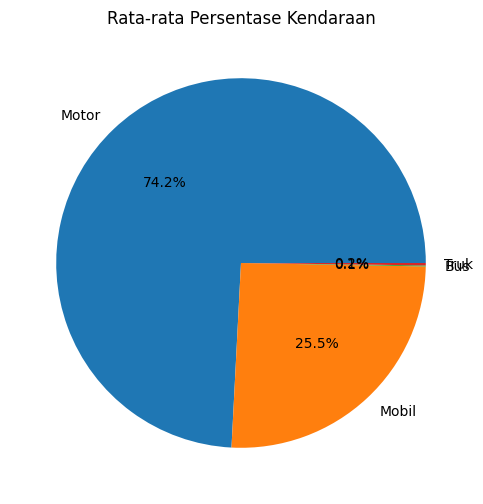

In [87]:
# PERSENTASE SELURUH JALAN
mean_motor = motor.mean()
mean_mobil = mobil.mean()
mean_bus = bus.mean()
mean_truk = truk.mean()
rata2 = {'Motor': mean_motor, 'Mobil': mean_mobil, 'Bus': mean_bus, 'Truk': mean_truk}
# rata2

import matplotlib.pyplot as plt
# color = ['cornflowerblue', 'blue', 'navy']
plt.figure(figsize=(10, 6))
plt.pie(rata2.values(), labels=rata2.keys(), autopct='%1.1f%%')
plt.title('Rata-rata Persentase Kendaraan')
# plt.xlabel('Jenis Kendaraan')
# plt.ylabel('Rata-rata Persentase')
plt.show()

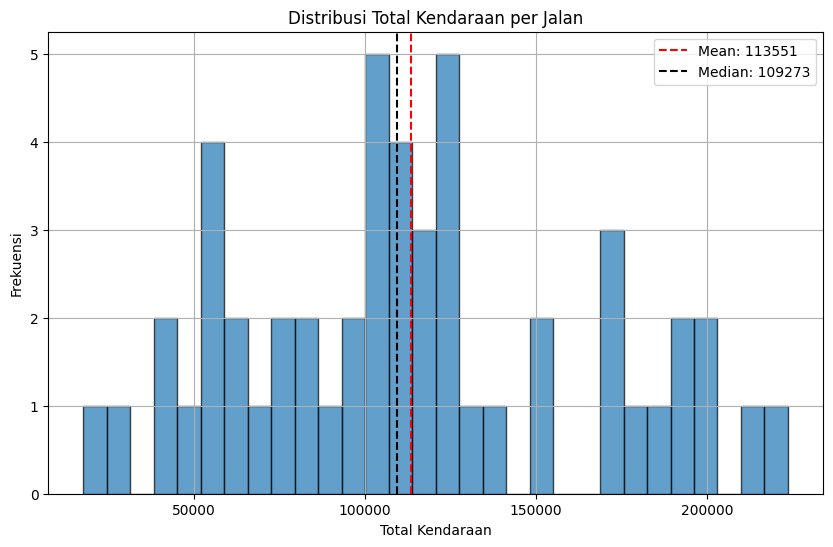

In [88]:
# DISTRIBUSI TOTAL KENDARAAN
plt.figure(figsize=(10, 6))
df_lhr['Total_Kendaraan'].hist(bins=30, edgecolor='black', alpha=0.7)
plt.axvline(df_lhr['Total_Kendaraan'].mean(), color='red', linestyle='--', label=f'Mean: {df_lhr["Total_Kendaraan"].mean():.0f}')
plt.axvline(df_lhr['Total_Kendaraan'].median(), color='black', linestyle='--', label=f'Median: {df_lhr["Total_Kendaraan"].median():.0f}')
plt.title('Distribusi Total Kendaraan per Jalan')
plt.xlabel('Total Kendaraan')
plt.ylabel('Frekuensi')
plt.legend()

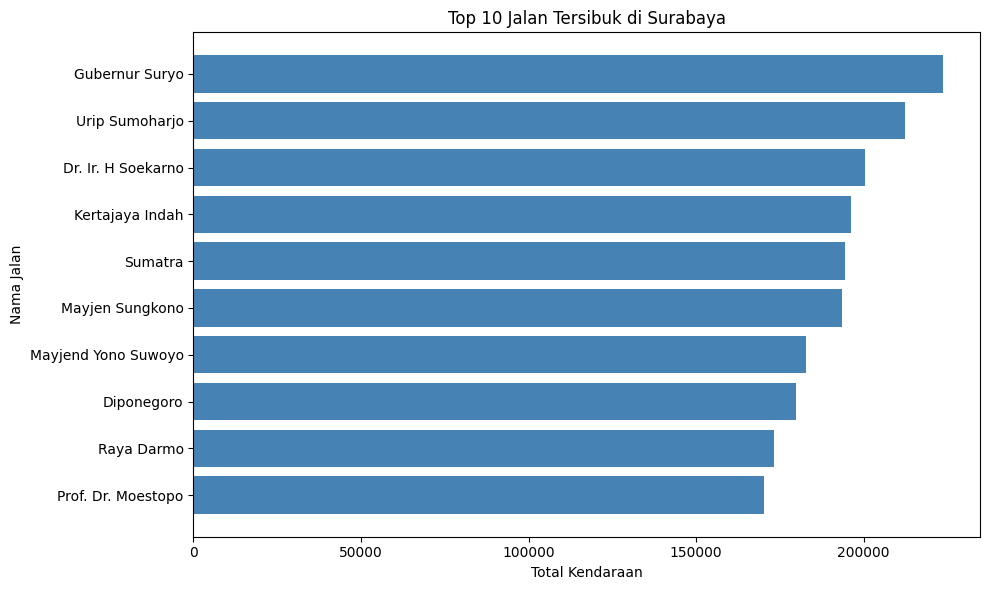

In [89]:
# 10 JALAN TERSIBUK KE SURABAYA
plt.figure(figsize=(10, 6))
top_10 = df_lhr.nlargest(10, 'Total_Kendaraan')
plt.barh(top_10['Nama Jalan'], top_10['Total_Kendaraan'], color='steelblue')
plt.title('Top 10 Jalan Tersibuk di Surabaya')
plt.xlabel('Total Kendaraan')
plt.ylabel('Nama Jalan')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

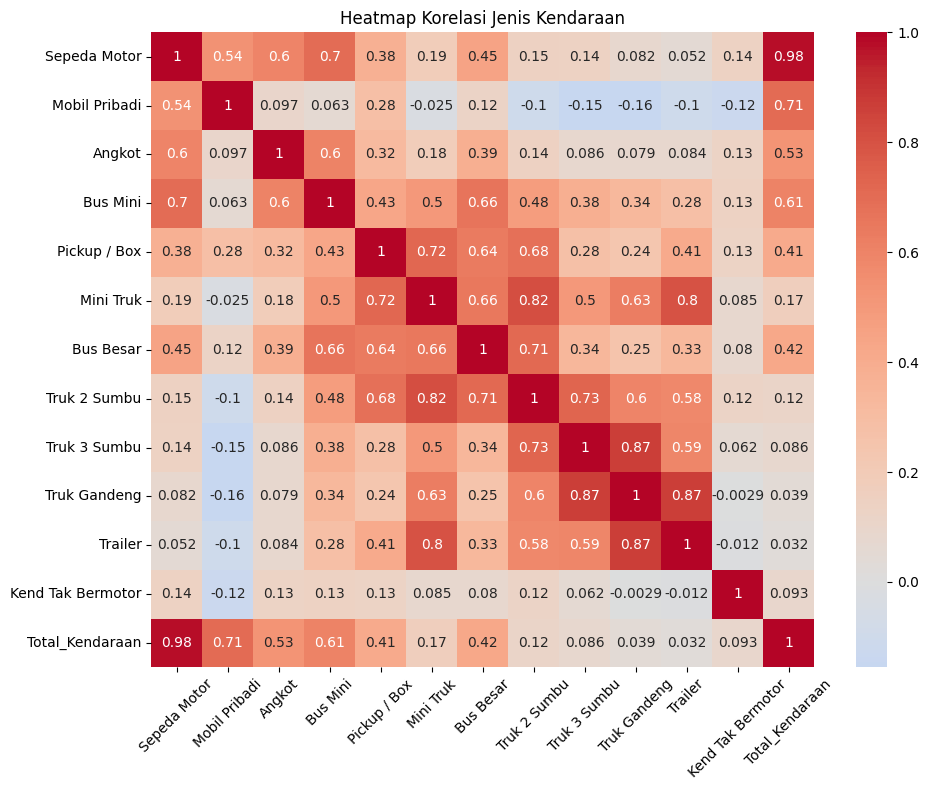

In [90]:
# kORELASI ANTARA JENIS KENDARAAN
import seaborn as sns
import matplotlib.pyplot as plt
correlation_matrix = df_lhr.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',center=0)
plt.title('Heatmap Korelasi Jenis Kendaraan')
plt.xticks(rotation=45)
plt.yticks()
plt.tight_layout()
plt.show()

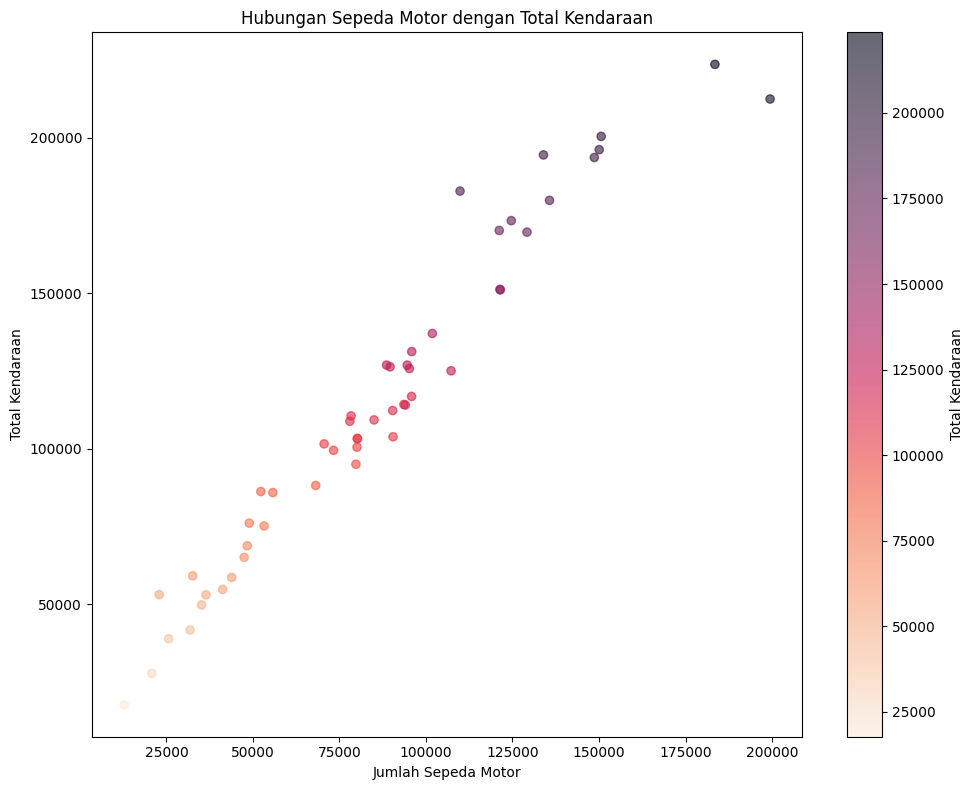

In [91]:
# KORELASI SEPEDA MOTOR DENGAN TOTAL KENDARAAN
# karena sepeda motor penyumbang terbesar jumlah kendaraan
plt.figure(figsize=(10, 8))
plt.scatter(df_lhr['Sepeda Motor'], df_lhr['Total_Kendaraan'], alpha=0.6, c=df_lhr['Total_Kendaraan'], cmap='rocket_r')
plt.colorbar(label='Total Kendaraan')
plt.title('Hubungan Sepeda Motor dengan Total Kendaraan')
plt.xlabel('Jumlah Sepeda Motor')
plt.ylabel('Total Kendaraan')
plt.tight_layout()

<Figure size 1000x800 with 0 Axes>

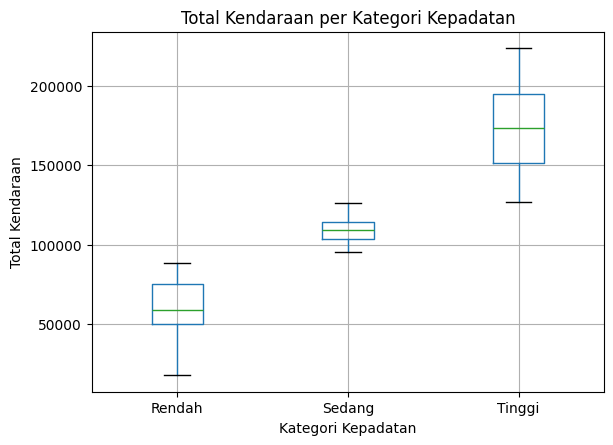

In [92]:
# TOTAL KENDARAAN
plt.figure(figsize=(10, 8))
bins = [df_lhr['Total_Kendaraan'].min(),
        df_lhr['Total_Kendaraan'].quantile(0.33),
        df_lhr['Total_Kendaraan'].quantile(0.66),
        df_lhr['Total_Kendaraan'].max()]
labels = ['Rendah', 'Sedang', 'Tinggi']
df_lhr['Kategori_Kepadatan'] = pd.cut(df_lhr['Total_Kendaraan'], bins=bins, labels=labels, include_lowest=True)
df_lhr.boxplot(column='Total_Kendaraan', by='Kategori_Kepadatan')
plt.title('Total Kendaraan per Kategori Kepadatan')
plt.suptitle('')
plt.xlabel('Kategori Kepadatan')
plt.ylabel('Total Kendaraan')
plt.show()

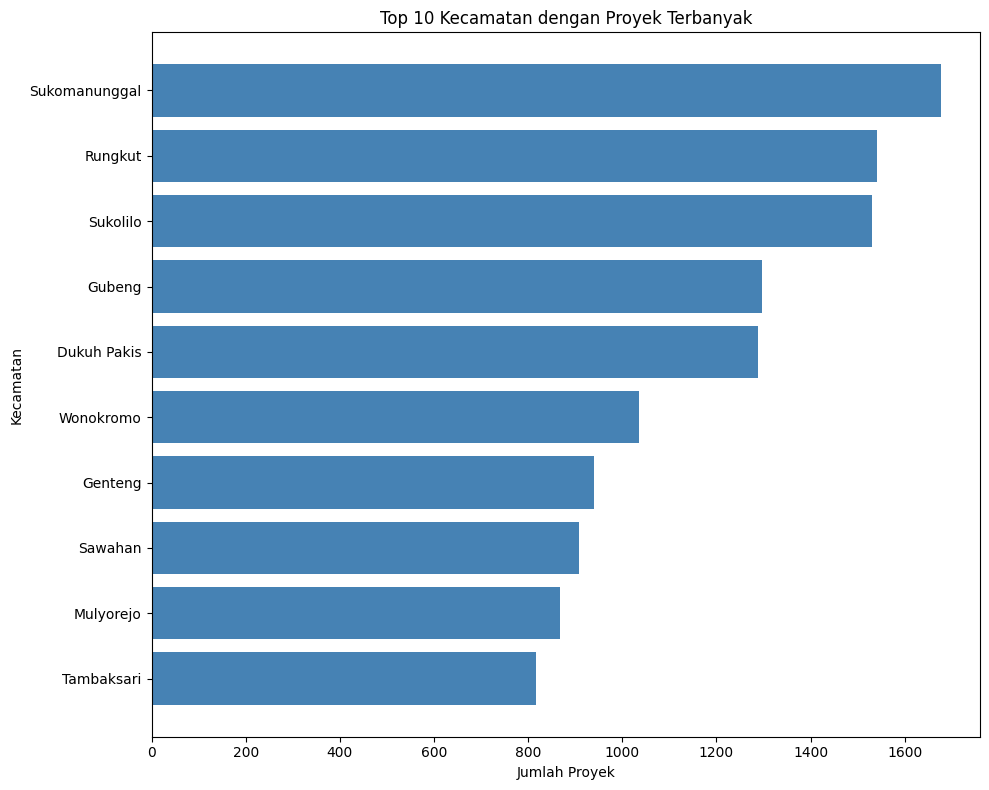

In [93]:
# KECAMATAN DENGAN PROYEK TERBANYAK
plt.figure(figsize=(10, 8))
top_10_kecamatan = df_pembangunan['Kecamatan'].value_counts().head(10)
plt.barh(top_10_kecamatan.index, top_10_kecamatan.values, color='steelblue')
plt.title('Top 10 Kecamatan dengan Proyek Terbanyak')
plt.xlabel('Jumlah Proyek')
plt.ylabel('Kecamatan')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [94]:
# GROUPBY BERDASARKAN NAMA JALAN
if 'Nama Jalan' in df_pembangunan.columns:
    jalan_pembangunan = df_pembangunan.groupby('Nama Jalan').agg({
        'Panjang Jalan': ['count', 'sum', 'mean'],
        'Lebar Jalan': 'sum',
        'Luasan Pengerjaan': 'sum',
    }).round(2)

    jalan_pembangunan.columns = ['Jumlah Proyek', 'Total Panjang', 'Rata2 Panjang', 'Total Lebar', 'Total Luas']
    jalan_pembangunan = pd.DataFrame(jalan_pembangunan)
    jalan_pembangunan = jalan_pembangunan.sort_values('Jumlah Proyek', ascending=False)

    display(jalan_pembangunan)


,Jumlah Proyek,Total Panjang,Rata2 Panjang,Total Lebar,Total Luas
Nama Jalan,,,,,
Margomulyo,304,2424.23,7.97,764.5,7082.30
Mayjend Yonosuwoyo,201,1066.89,5.31,519.0,2846.73
Dr. Ir. H. Soekarno,198,6757.00,34.13,412.7,14767.80
H.R. Muhammad,197,1556.15,7.90,429.6,3714.45
Pandugo,178,3166.69,17.79,388.0,7605.24
...,...,...,...,...,...
Bangkingan Vi Blok Xd,1,12.00,12.00,2.0,24.00
Ubi Viii,1,7.50,7.50,6.0,45.00
Yos Sudarso,1,1.00,1.00,1.0,1.00


In [95]:
proyek = jalan_pembangunan['Jumlah Proyek'].sum()
proyek

np.int64(23150)

In [96]:
# JALAN YANG SERING ADA PERBAIKAN
if 'Nama Jalan' in df.columns:
    sering = df['Nama Jalan'].value_counts().head(10)
# sering

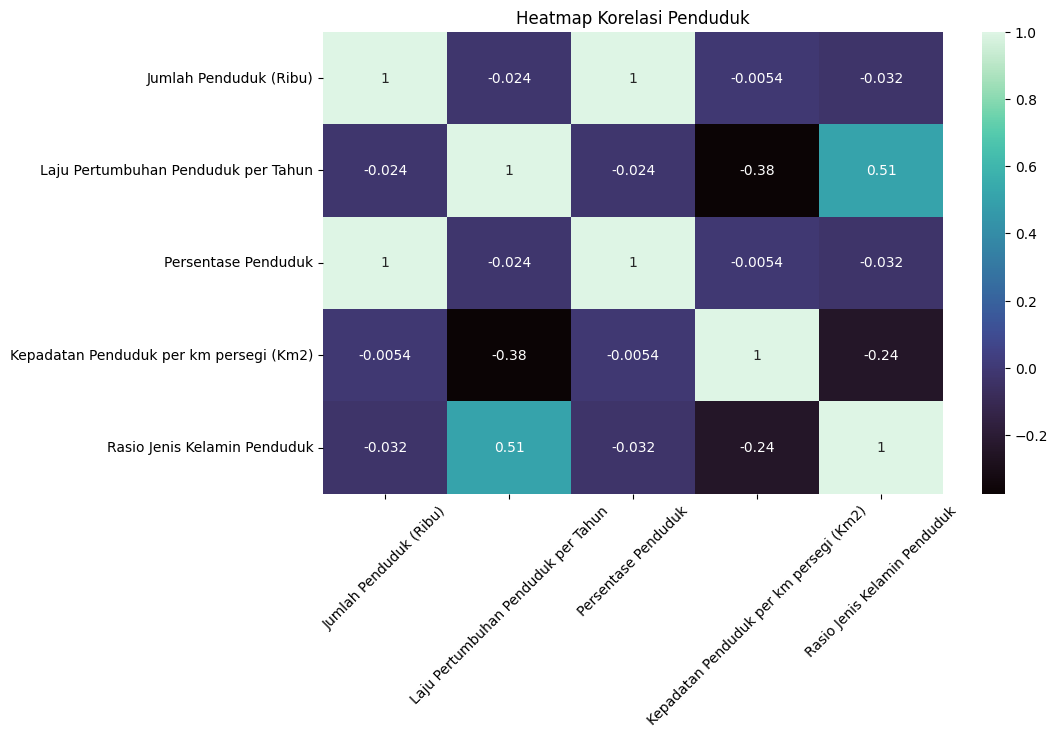

In [97]:
# KORELASI ANTAR FITUR
plt.figure(figsize=(10,6))
sns.heatmap(df_penduduk.select_dtypes(include=['number']).corr(), annot=True, cmap='mako')
plt.title('Heatmap Korelasi Penduduk')
plt.xticks(rotation=45)
plt.show()

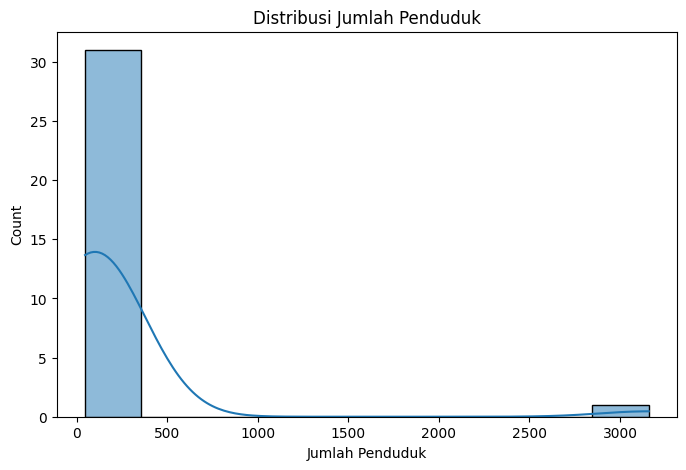

In [98]:
# DISTRIBUSI JUMLAH PENDUDUK
plt.figure(figsize=(8,5))
sns.histplot(df_penduduk['Jumlah Penduduk (Ribu)'], bins=10, kde=True)
plt.title('Distribusi Jumlah Penduduk')
plt.xlabel('Jumlah Penduduk')
plt.show()

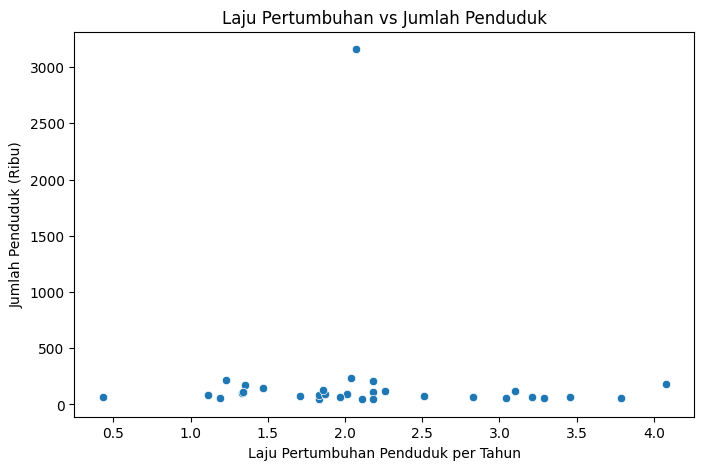

In [99]:
# LAJU PERTUMBUHAN PENDUDUK DIBANDINGKAN JUMLAH PENDUDUK
plt.figure(figsize=(8,5))
sns.scatterplot(x='Laju Pertumbuhan Penduduk per Tahun', y='Jumlah Penduduk (Ribu)', data=df_penduduk)
plt.title('Laju Pertumbuhan vs Jumlah Penduduk')
plt.show()

# MARGING DATASET

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_merge1 = pd.merge(df_lhr, jalan_pembangunan, on='Nama Jalan', how='left')
print(f"Shape df_lhr          : {df_lhr.shape}")
print(f"Shape df_pembangunan  : {jalan_pembangunan.shape}")
print(f"Shape setelah merging : {df_merge1.shape}")
# df_merge1 = df_merge1.dropna(inplace=True)
df_merge1 = pd.DataFrame(df_merge1)
# df_merge1

Shape df_lhr          : (102, 14)
Shape df_pembangunan  : (1759, 5)
Shape setelah merging : (102, 19)


In [47]:
print(df_merge1.columns)

Index(['Nama Jalan', 'Sepeda Motor', 'Mobil Pribadi', 'Angkot', 'Bus Mini',
       'Pickup / Box', 'Mini Truk', 'Bus Besar', 'Truk 2 Sumbu',
       'Truk 3 Sumbu', 'Truk Gandeng', 'Trailer', 'Kend Tak Bermotor', 'Tahun',
       'Total_Kendaraan', 'Kategori_Kepadatan', 'Jumlah Proyek',
       'Total Panjang', 'Rata2 Panjang', 'Total Lebar', 'Total Luas'],
      dtype='object')


In [48]:
nama_jalan_kecamatan = df_pembangunan[['Nama Jalan', 'Kecamatan']].drop_duplicates(subset=['Nama Jalan']).set_index('Nama Jalan')
df_merge1 = df_merge1.merge(nama_jalan_kecamatan, on='Nama Jalan', how='left')

df_merge = pd.merge(df_merge1, df_penduduk, on='Kecamatan', how='left')
print(f"Shape df_merge1       : {df_merge1.shape}")
print(f"Shape df_penduduk     : {df_penduduk.shape}")
print(f"Shape setelah merging : {df_merge.shape}")
df_merge = pd.DataFrame(df_merge)
df_merge

Shape df_merge1       : (51, 22)
Shape df_penduduk     : (32, 6)
Shape setelah merging : (51, 27)


,Nama Jalan,Sepeda Motor,Mobil Pribadi,Angkot,Bus Mini,Pickup / Box,Mini Truk,Bus Besar,Truk 2 Sumbu,Truk 3 Sumbu,...,Total Panjang,Rata2 Panjang,Total Lebar,Total Luas,Kecamatan,Jumlah Penduduk (Ribu),Laju Pertumbuhan Penduduk per Tahun,Persentase Penduduk,Kepadatan Penduduk per km persegi (Km2),Rasio Jenis Kelamin Penduduk
0,Adityawarman,94572,30049,421,49,1094,215,40,52,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Basuki Rahmat,121455,25879,501,66,765,58,83,5,0,...,401.75,19.13,27.50,573.62,Genteng,63.2,1.97,2.00,15593.0,96.8
2,Blauran,70576,29627,268,44,798,49,26,10,0,...,2.00,2.00,1.00,2.00,Genteng,63.2,1.97,2.00,15593.0,96.8
3,Bubutan,55753,27405,334,0,2045,100,77,29,0,...,792.86,9.79,249.00,2791.96,Bubutan,107.8,1.34,3.41,27933.0,98.9
4,Dharmawangsa,73289,24347,482,26,779,98,61,0,0,...,417.50,23.19,62.50,1366.50,Gubeng,143.9,1.47,4.55,18004.0,96.3
5,Dinoyo,79762,13304,613,33,789,86,24,6,4,...,189.50,6.11,55.75,377.50,Tegalsari,108.1,1.34,3.42,25193.0,97.7
6,Diponegoro,135693,40628,1028,84,1655,122,56,43,0,...,1870.63,29.23,138.50,4583.21,Wonokromo,170.0,1.35,5.38,20069.0,97.2
7,Dr. Soetomo,89619,35370,341,11,772,56,0,2,1,...,857.56,24.50,153.50,6942.76,Tegalsari,108.1,1.34,3.42,25193.0,97.7
8,Embong Malang,90379,21006,414,40,169,39,78,0,11,...,186.40,23.30,8.75,189.40,Tegalsari,108.1,1.34,3.42,25193.0,97.7
9,Gemblongan,35166,13738,218,15,517,24,44,24,0,...,178.00,9.37,54.00,466.00,Bubutan,107.8,1.34,3.41,27933.0,98.9


In [50]:
df_merge.isna().sum()

,0
Nama Jalan,0
Sepeda Motor,0
Mobil Pribadi,0
Angkot,0
Bus Mini,0
Pickup / Box,0
Mini Truk,0
Bus Besar,0
Truk 2 Sumbu,0
Truk 3 Sumbu,0


In [51]:
# MENGHAPUS NULL VALUE
df_merge = df_merge.dropna(subset=['Jumlah Proyek', 'Total Panjang',	'Rata2 Panjang',	'Total Lebar',	'Total Luas',	'Kecamatan',	'Jumlah Penduduk (Ribu)',	'Laju Pertumbuhan Penduduk per Tahun', 'Persentase Penduduk',	'Kepadatan Penduduk per km persegi (Km2)',	'Rasio Jenis Kelamin Penduduk']).reset_index(drop=True)
df_merge = pd.DataFrame(df_merge)
df_merge

,Nama Jalan,Sepeda Motor,Mobil Pribadi,Angkot,Bus Mini,Pickup / Box,Mini Truk,Bus Besar,Truk 2 Sumbu,Truk 3 Sumbu,...,Total Panjang,Rata2 Panjang,Total Lebar,Total Luas,Kecamatan,Jumlah Penduduk (Ribu),Laju Pertumbuhan Penduduk per Tahun,Persentase Penduduk,Kepadatan Penduduk per km persegi (Km2),Rasio Jenis Kelamin Penduduk
0,Basuki Rahmat,121455,25879,501,66,765,58,83,5,0,...,401.75,19.13,27.50,573.62,Genteng,63.2,1.97,2.00,15593.0,96.8
1,Blauran,70576,29627,268,44,798,49,26,10,0,...,2.00,2.00,1.00,2.00,Genteng,63.2,1.97,2.00,15593.0,96.8
2,Bubutan,55753,27405,334,0,2045,100,77,29,0,...,792.86,9.79,249.00,2791.96,Bubutan,107.8,1.34,3.41,27933.0,98.9
3,Dharmawangsa,73289,24347,482,26,779,98,61,0,0,...,417.50,23.19,62.50,1366.50,Gubeng,143.9,1.47,4.55,18004.0,96.3
4,Dinoyo,79762,13304,613,33,789,86,24,6,4,...,189.50,6.11,55.75,377.50,Tegalsari,108.1,1.34,3.42,25193.0,97.7
5,Diponegoro,135693,40628,1028,84,1655,122,56,43,0,...,1870.63,29.23,138.50,4583.21,Wonokromo,170.0,1.35,5.38,20069.0,97.2
6,Dr. Soetomo,89619,35370,341,11,772,56,0,2,1,...,857.56,24.50,153.50,6942.76,Tegalsari,108.1,1.34,3.42,25193.0,97.7
7,Embong Malang,90379,21006,414,40,169,39,78,0,11,...,186.40,23.30,8.75,189.40,Tegalsari,108.1,1.34,3.42,25193.0,97.7
8,Gemblongan,35166,13738,218,15,517,24,44,24,0,...,178.00,9.37,54.00,466.00,Bubutan,107.8,1.34,3.41,27933.0,98.9
9,Genteng Kali,78004,28853,269,5,1462,29,1,4,0,...,95.00,5.59,40.50,262.00,Genteng,63.2,1.97,2.00,15593.0,96.8


In [103]:
df_merge.to_csv('final_merge_data.csv', index=False)

Text(0.05, 0.95, 'Korelasi: 0.205')

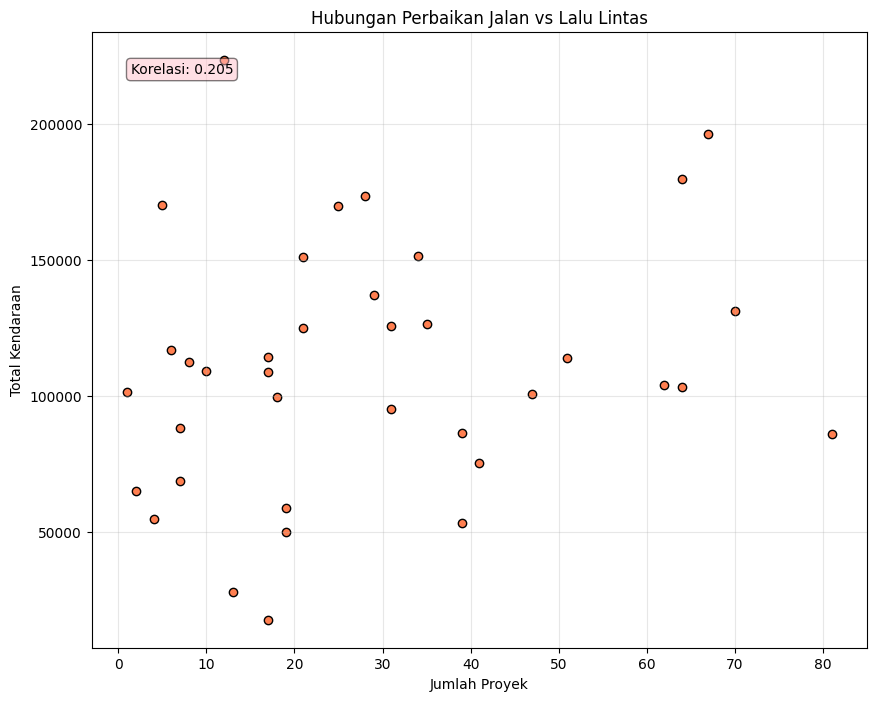

In [52]:
# KORELASI LALU LINTAS DAN PERBAIKAN JALAN
plt.figure(figsize=(10,8))
plt.scatter(df_merge['Jumlah Proyek'], df_merge['Total_Kendaraan'], c='coral', edgecolors='black')
plt.xlabel('Jumlah Proyek')
plt.ylabel('Total Kendaraan')
plt.title('Hubungan Perbaikan Jalan vs Lalu Lintas')
plt.grid(True, alpha=0.3)

ax = plt.gca() # Get the current axes
corr2 = df_merge[['Jumlah Proyek', 'Total_Kendaraan']].corr().iloc[0,1]
plt.text(0.05, 0.95, f'Korelasi: {corr2:.3f}',
         transform=ax.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='pink', alpha=0.5))

Text(0.05, 0.95, 'Korelasi: -0.239')

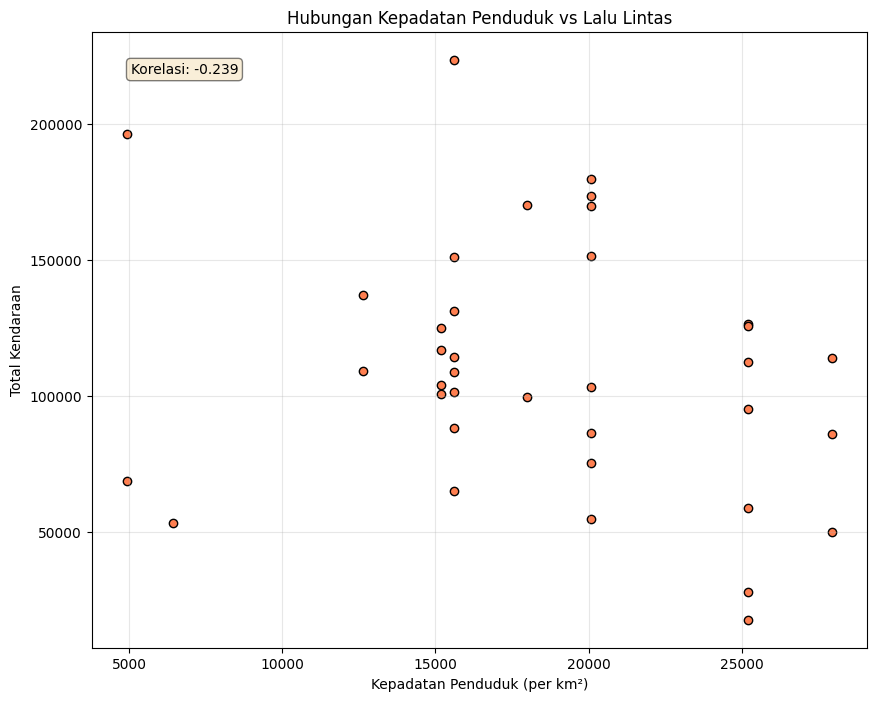

In [53]:
# KORELASI LALU LINTAS DAN KEPADATAN PENDUDUK
plt.figure(figsize=(10,8))
plt.scatter(df_merge['Kepadatan Penduduk per km persegi (Km2)'], df_merge['Total_Kendaraan'], c='coral', edgecolors='black')
plt.xlabel('Kepadatan Penduduk (per km²)')
plt.ylabel('Total Kendaraan')
plt.title('Hubungan Kepadatan Penduduk vs Lalu Lintas')
plt.grid(True, alpha=0.3)

ax = plt.gca() # Get the current axes
corr2 = df_merge[['Kepadatan Penduduk per km persegi (Km2)', 'Total_Kendaraan']].corr().iloc[0,1]
plt.text(0.05, 0.95, f'Korelasi: {corr2:.3f}',
         transform=ax.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

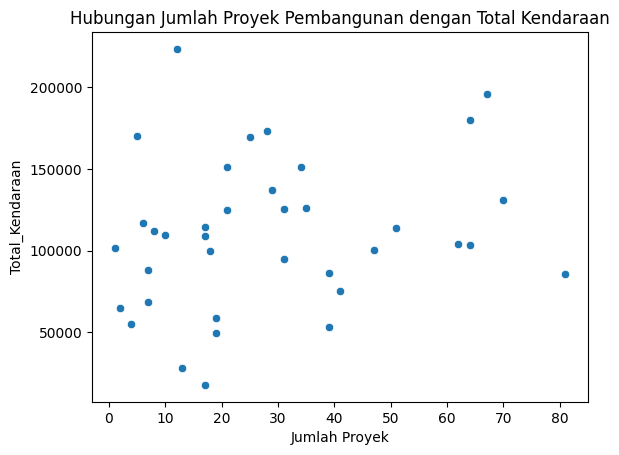

In [54]:
# hubungan antara total kendaraan dengan jumlah proyek
sns.scatterplot(x='Jumlah Proyek', y='Total_Kendaraan', data=df_merge)
plt.title('Hubungan Jumlah Proyek Pembangunan dengan Total Kendaraan')
plt.show()

In [59]:
!pip install pingouin
import pingouin as pg

# korelasi parsial bisa dilakukan dengan library pingouin
partial_corr = pg.partial_corr(data=df_merge, x='Jumlah Proyek', y='Total_Kendaraan', covar=['Jumlah Penduduk (Ribu)'])
print(partial_corr)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 7.1 MB/s eta 0:00:00
          n         r          CI95%     p-val
pearson  37  0.191252  [-0.15, 0.49]  0.263838


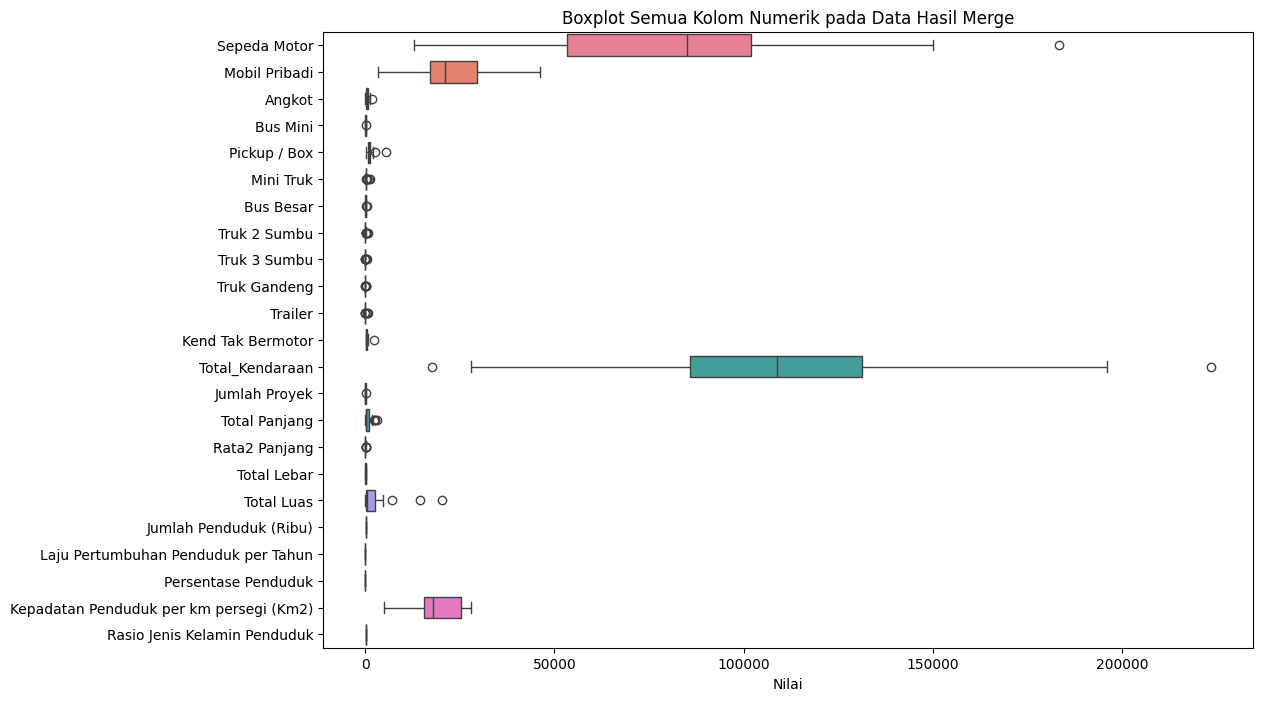

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_boxplot_all_numeric(df):
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    plt.figure(figsize=(12, 8))
    sns.boxplot(data=df[numeric_cols], orient='h')
    plt.title('Boxplot Semua Kolom Numerik pada Data Hasil Merge')
    plt.xlabel('Nilai')
    plt.show()
plot_boxplot_all_numeric(df_merge)